# Notebook 7: Final Test Evaluation

This notebook evaluates the final selected Tuned XGBoost model on the untouched test set.

Final model decision based on professor feedback:

- Main final model: Tuned XGBoost
- Main balanced threshold: 0.50
- Recall-focused screening threshold: 0.45

The test set is used only in this notebook for final evaluation.

In [2]:
# Step 1: Load model, preprocessor, and prepare test set safely

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import joblib

from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")

# 1. Define RareCategoryGrouper exactly but safely

class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_frequency=10, rare_label="Rare"):
        self.min_frequency = min_frequency
        self.rare_label = rare_label

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).astype(str)

        self.frequent_categories_ = []

        for column in X_df.columns:
            value_counts = X_df[column].value_counts(dropna=False)
            frequent_categories = value_counts[
                value_counts >= self.min_frequency
            ].index.astype(str).tolist()

            self.frequent_categories_.append(frequent_categories)

        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).astype(str).copy()

        for column_index, column in enumerate(X_df.columns):

            # Handles old saved preprocessor format: list
            if isinstance(self.frequent_categories_, list):
                frequent_categories = self.frequent_categories_[column_index]

            # Handles dictionary format if ever used
            elif isinstance(self.frequent_categories_, dict):
                frequent_categories = self.frequent_categories_.get(
                    column,
                    []
                )

            else:
                raise TypeError(
                    "Unsupported frequent_categories_ format."
                )

            X_df[column] = np.where(
                X_df[column].isin(frequent_categories),
                X_df[column],
                self.rare_label
            )

        return X_df


# 2. Detect project root

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT = None

for candidate in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]:
    if (candidate / "data" / "processed" / "diabetic_modeling_data_final.csv").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate project root."
    )

print(f"Project root detected: {PROJECT_ROOT}")

# 3. Define paths

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "diabetic_modeling_data_final.csv"
SCHEMA_PATH = PROJECT_ROOT / "data" / "processed" / "model_feature_schema.json"
SPLIT_PATH = PROJECT_ROOT / "data" / "processed" / "patient_split_assignments.csv"

MODELS_PATH = PROJECT_ROOT / "models"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"
METRICS_PATH = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"

METRICS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# 4. Load final Tuned XGBoost model

FINAL_MODEL_PATH = MODELS_PATH / "notebook_6_best_tuned_xgboost.joblib"

if not FINAL_MODEL_PATH.exists():
    FINAL_MODEL_PATH = MODELS_PATH / "notebook_6_selected_final_candidate_model.joblib"

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Final Tuned XGBoost model file not found in models folder."
    )

final_model = joblib.load(FINAL_MODEL_PATH)

print(f"Final model loaded from: {FINAL_MODEL_PATH}")

# 5. Load fitted preprocessor

PREPROCESSOR_PATH = MODELS_PATH / "notebook_4_fitted_preprocessor.joblib"

if not PREPROCESSOR_PATH.exists():
    raise FileNotFoundError(
        "Fitted preprocessor file not found: notebook_4_fitted_preprocessor.joblib"
    )

preprocessor = joblib.load(PREPROCESSOR_PATH)

print(f"Fitted preprocessor loaded from: {PREPROCESSOR_PATH}")

# 6. Load dataset, schema, and split assignments

df = pd.read_csv(DATA_PATH)

with open(SCHEMA_PATH, "r") as file:
    feature_schema = json.load(file)

split_assignments = pd.read_csv(SPLIT_PATH)

numeric_features = feature_schema["numeric_model_features"]
categorical_features = feature_schema["categorical_model_features"]
target_column = feature_schema["target_column"]
group_split_column = feature_schema["group_split_column"]

predictor_columns = numeric_features + categorical_features

print("\nData loaded.")
print(f"Dataset shape: {df.shape}")
print(f"Split assignment shape before cleaning: {split_assignments.shape}")
print(f"Numeric predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
print(f"Total predictors: {len(predictor_columns)}")

# 7. Fix split assignment duplication issue
# We need one split row per patient, not one row per encounter.

if group_split_column not in split_assignments.columns:
    raise ValueError(
        f"Split assignment file does not contain {group_split_column}."
    )

if "split" not in split_assignments.columns:
    raise ValueError(
        "Split assignment file does not contain split column."
    )

# Check if any patient has more than one split
patient_split_check = (
    split_assignments
    .groupby(group_split_column)["split"]
    .nunique()
)

patients_with_multiple_splits = patient_split_check[
    patient_split_check > 1
]

if len(patients_with_multiple_splits) > 0:
    raise ValueError(
        "Some patients are assigned to more than one split. "
        "This would cause leakage."
    )

# Keep one split record per patient
patient_level_splits = (
    split_assignments[[group_split_column, "split"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Split assignment shape after patient-level deduplication: {patient_level_splits.shape}")

# Confirm expected split distribution by unique patients
print("\nUnique patient split counts:")
print(patient_level_splits["split"].value_counts())

# 8. Merge split assignment safely

df_with_split = df.merge(
    patient_level_splits,
    on=group_split_column,
    how="left",
    validate="many_to_one"
)

missing_split_count = df_with_split["split"].isna().sum()

if missing_split_count > 0:
    raise ValueError(
        f"{missing_split_count} rows do not have split assignments."
    )

print("\nEncounter split counts after safe merge:")
print(df_with_split["split"].value_counts())

# 9. Isolate untouched test set

test_df = df_with_split[
    df_with_split["split"] == "test"
].copy()

X_test_raw = test_df[predictor_columns].copy()
y_test = test_df[target_column].copy()

print("\nUntouched test set prepared successfully.")
print(f"Test rows: {X_test_raw.shape[0]}")
print(f"Test predictors: {X_test_raw.shape[1]}")
print(f"Test positive class rate: {y_test.mean() * 100:.2f}%")
print(f"Test readmitted count: {int(y_test.sum())}")
print(f"Test not-readmitted count: {int((y_test == 0).sum())}")

# 10. Apply saved preprocessing to test set

X_test_preprocessed = preprocessor.transform(X_test_raw)

print("\nPreprocessing applied to test set.")
print(f"Raw test shape: {X_test_raw.shape}")
print(f"Preprocessed test shape: {X_test_preprocessed.shape}")

# 11. Final confirmation

print("\nNotebook 7 Step 1 completed successfully.")
print("- Final Tuned XGBoost model loaded.")
print("- Saved training-fitted preprocessor loaded.")
print("- Split assignment safely merged without duplication.")
print("- Untouched test set prepared.")
print("- Test set transformed without refitting preprocessing.")

Project root detected: C:\Users\pradh\Documents\hospital-readmission-project
Final model loaded from: C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_6_best_tuned_xgboost.joblib
Fitted preprocessor loaded from: C:\Users\pradh\Documents\hospital-readmission-project\models\notebook_4_fitted_preprocessor.joblib

Data loaded.
Dataset shape: (99343, 46)
Split assignment shape before cleaning: (99343, 4)
Numeric predictors: 8
Categorical predictors: 35
Total predictors: 43
Split assignment shape after patient-level deduplication: (69990, 2)

Unique patient split counts:
split
train         48993
test          10499
validation    10498
Name: count, dtype: int64

Encounter split counts after safe merge:
split
train         69467
test          14976
validation    14900
Name: count, dtype: int64

Untouched test set prepared successfully.
Test rows: 14976
Test predictors: 43
Test positive class rate: 11.34%
Test readmitted count: 1698
Test not-readmitted count: 13278

Prepro

In [ ]:
# Step 2: Evaluate final Tuned XGBoost on test set at two thresholds

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

# 1. Generate test-set predicted probabilities

y_test_probability = final_model.predict_proba(X_test_preprocessed)[:, 1]

print("Test probabilities generated successfully.")
print(f"Number of test predictions: {len(y_test_probability)}")
print(f"Minimum probability: {y_test_probability.min():.4f}")
print(f"Maximum probability: {y_test_probability.max():.4f}")
print(f"Mean probability: {y_test_probability.mean():.4f}")

# 2. Define evaluation function

def evaluate_threshold(y_true, y_probability, threshold, label):
    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    results = {
        "model": "Tuned XGBoost",
        "operating_point": label,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "predicted_positive_rate": y_pred.mean(),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

    return results

# 3. Evaluate professor-approved thresholds

threshold_results = [
    evaluate_threshold(
        y_true=y_test,
        y_probability=y_test_probability,
        threshold=0.50,
        label="Main balanced threshold"
    ),
    evaluate_threshold(
        y_true=y_test,
        y_probability=y_test_probability,
        threshold=0.45,
        label="Recall-focused screening threshold"
    ),
]

final_test_results = pd.DataFrame(threshold_results)


# 4. Display final test results

display_results = final_test_results.copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
]

display_results[percentage_columns] = (
    display_results[percentage_columns] * 100
)

display_columns = [
    "model",
    "operating_point",
    "threshold",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "predicted_positive_rate",
    "true_negatives",
    "false_positives",
    "false_negatives",
    "true_positives",
]

print("\nFinal Tuned XGBoost Test Performance")
print("-" * 140)

print(
    display_results[display_columns]
    .round(2)
    .to_string(index=False)
)


# 5. Save final test metrics

final_test_metrics_path = (
    METRICS_PATH
    / "notebook_7_final_xgboost_test_metrics.csv"
)

final_test_results.to_csv(
    final_test_metrics_path,
    index=False
)

print(f"Final test metrics saved at: {final_test_metrics_path}")

Test probabilities generated successfully.
Number of test predictions: 14976
Minimum probability: 0.0687
Maximum probability: 0.9570
Mean probability: 0.4488

Final Tuned XGBoost Test Performance
--------------------------------------------------------------------------------------------------------------------------------------------
        model                    operating_point  threshold  accuracy  balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  roc_auc  pr_auc  predicted_positive_rate  true_negatives  false_positives  false_negatives  true_positives
Tuned XGBoost            Main balanced threshold       0.50     65.37              61.08      17.55               55.54        66.63     26.67    66.39   22.38                    35.88            8847             4431              755             943
Tuned XGBoost Recall-focused screening threshold       0.45     55.85              60.80      15.86               67.20        54.40     25.66    66.39   22.38  

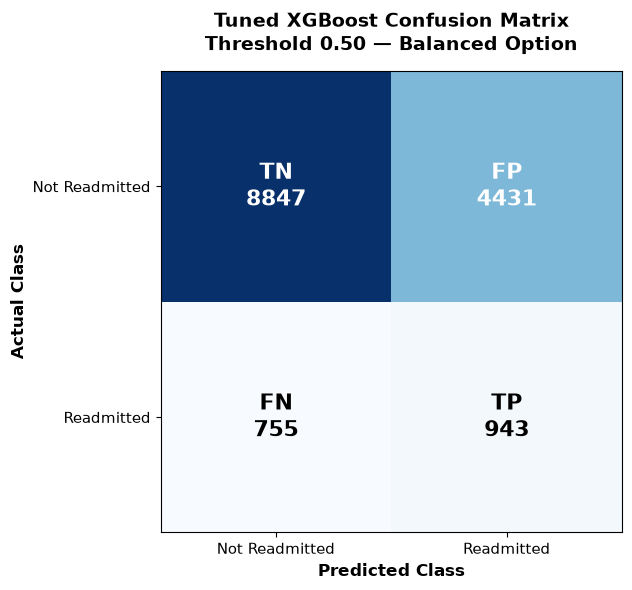

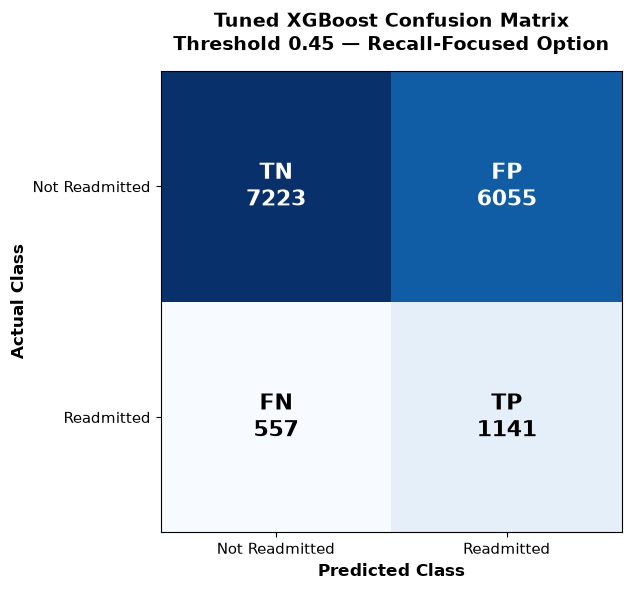

Final confusion matrix plots saved successfully.
Threshold 0.50 plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_confusion_matrix_threshold_050.png
Threshold 0.45 plot: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_confusion_matrix_threshold_045.png


In [14]:
# ============================================================
# Notebook 7: Final Test Evaluation
# Step 3: Final clean confusion matrix plots
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------
# 1. Create predictions for both thresholds
# ------------------------------------------------------------

y_test_pred_050 = (y_test_probability >= 0.50).astype(int)
y_test_pred_045 = (y_test_probability >= 0.45).astype(int)


# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def plot_final_confusion_matrix(
    y_true,
    y_pred,
    threshold,
    option_name,
    save_path
):
    cm = confusion_matrix(y_true, y_pred)

    labels = np.array([
        [f"TN\n{cm[0, 0]}", f"FP\n{cm[0, 1]}"],
        [f"FN\n{cm[1, 0]}", f"TP\n{cm[1, 1]}"]
    ])

    fig, ax = plt.subplots(figsize=(7, 6))

    image = ax.imshow(
        cm,
        cmap="Blues"
    )

    # Add text labels
    for row in range(2):
        for col in range(2):
            ax.text(
                col,
                row,
                labels[row, col],
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="white" if cm[row, col] > cm.max() / 2 else "black"
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        ["Not Readmitted", "Readmitted"],
        fontsize=11
    )

    ax.set_yticklabels(
        ["Not Readmitted", "Readmitted"],
        fontsize=11
    )

    ax.set_xlabel(
        "Predicted Class",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Actual Class",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_title(
        f"Tuned XGBoost Confusion Matrix\n"
        f"Threshold {threshold:.2f} — {option_name}",
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()


# ------------------------------------------------------------
# 3. Threshold 0.50 confusion matrix
# ------------------------------------------------------------

confusion_matrix_050_path = (
    FIGURES_PATH
    / "notebook_7_final_confusion_matrix_threshold_050.png"
)

plot_final_confusion_matrix(
    y_true=y_test,
    y_pred=y_test_pred_050,
    threshold=0.50,
    option_name="Balanced Option",
    save_path=confusion_matrix_050_path
)


# ------------------------------------------------------------
# 4. Threshold 0.45 confusion matrix
# ------------------------------------------------------------

confusion_matrix_045_path = (
    FIGURES_PATH
    / "notebook_7_final_confusion_matrix_threshold_045.png"
)

plot_final_confusion_matrix(
    y_true=y_test,
    y_pred=y_test_pred_045,
    threshold=0.45,
    option_name="Recall-Focused Option",
    save_path=confusion_matrix_045_path
)


# ------------------------------------------------------------
# 5. Print saved paths
# ------------------------------------------------------------

print("Final confusion matrix plots saved successfully.")
print(f"Threshold 0.50 plot: {confusion_matrix_050_path}")
print(f"Threshold 0.45 plot: {confusion_matrix_045_path}")

Curve metrics calculated successfully.
ROC-AUC: 66.39%
PR-AUC: 22.38%
Test positive class rate: 11.34%


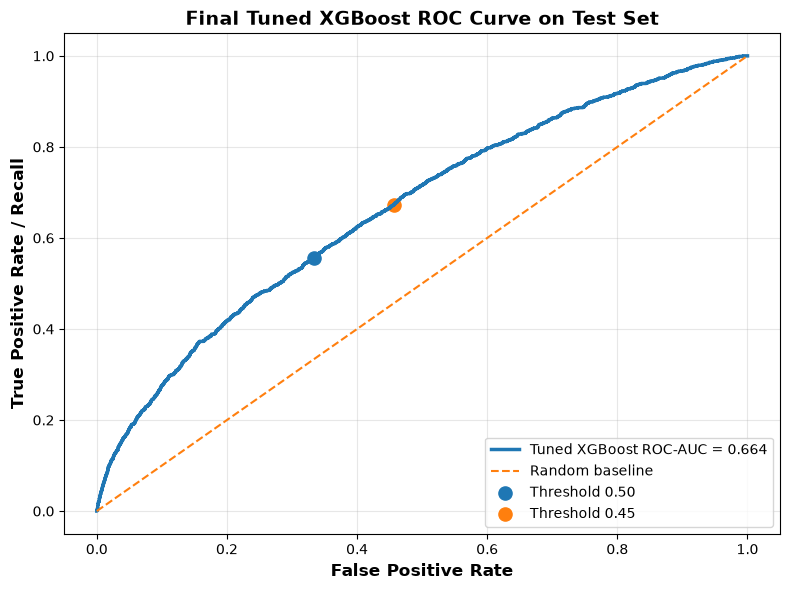

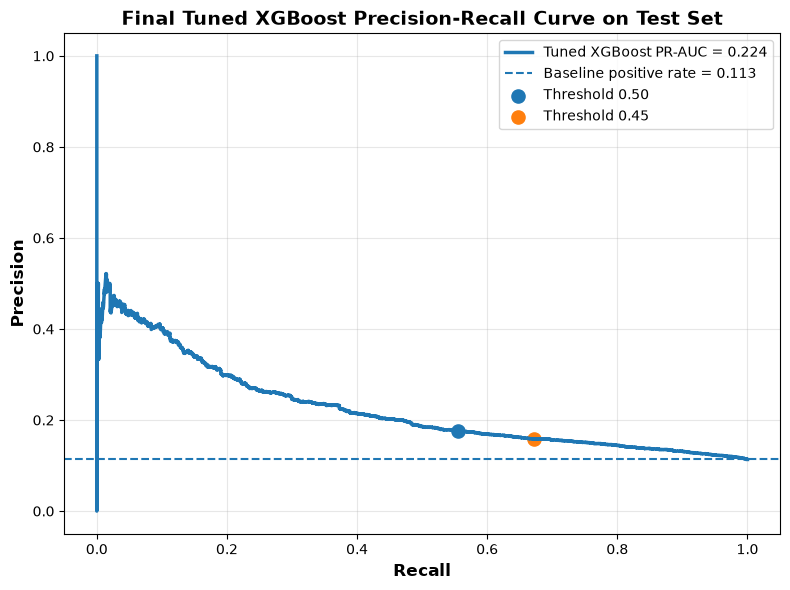

ROC and Precision-Recall curves saved successfully.
ROC curve saved at: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_xgboost_roc_curve.png
Precision-Recall curve saved at: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_xgboost_precision_recall_curve.png


In [16]:
# Step 4: ROC Curve and Precision-Recall Curve for Final XGBoost

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
# 1. Calculate ROC and PR curve values

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_probability
)

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_probability
)

roc_auc_value = roc_auc_score(
    y_test,
    y_test_probability
)

pr_auc_value = average_precision_score(
    y_test,
    y_test_probability
)

positive_class_rate = y_test.mean()

print("Curve metrics calculated successfully.")
print(f"ROC-AUC: {roc_auc_value * 100:.2f}%")
print(f"PR-AUC: {pr_auc_value * 100:.2f}%")
print(f"Test positive class rate: {positive_class_rate * 100:.2f}%")

# 2. Helper function to calculate threshold points

def get_threshold_curve_point(y_true, y_probability, threshold):
    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    threshold_recall = tp / (tp + fn)
    threshold_precision = tp / (tp + fp)
    threshold_fpr = fp / (fp + tn)
    threshold_tpr = threshold_recall

    return {
        "threshold": threshold,
        "precision": threshold_precision,
        "recall": threshold_recall,
        "fpr": threshold_fpr,
        "tpr": threshold_tpr,
    }


threshold_050_point = get_threshold_curve_point(
    y_true=y_test,
    y_probability=y_test_probability,
    threshold=0.50
)

threshold_045_point = get_threshold_curve_point(
    y_true=y_test,
    y_probability=y_test_probability,
    threshold=0.45
)

# 3. ROC curve

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"Tuned XGBoost ROC-AUC = {roc_auc_value:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random baseline"
)

ax.scatter(
    threshold_050_point["fpr"],
    threshold_050_point["tpr"],
    s=90,
    label="Threshold 0.50"
)

ax.scatter(
    threshold_045_point["fpr"],
    threshold_045_point["tpr"],
    s=90,
    label="Threshold 0.45"
)

ax.set_title(
    "Final Tuned XGBoost ROC Curve on Test Set",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "True Positive Rate / Recall",
    fontsize=12,
    fontweight="bold"
)

ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()

roc_curve_path = (
    FIGURES_PATH
    / "notebook_7_final_xgboost_roc_curve.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 4. Precision-Recall curve

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    recall,
    precision,
    linewidth=2.5,
    label=f"Tuned XGBoost PR-AUC = {pr_auc_value:.3f}"
)

ax.axhline(
    positive_class_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline positive rate = {positive_class_rate:.3f}"
)

ax.scatter(
    threshold_050_point["recall"],
    threshold_050_point["precision"],
    s=90,
    label="Threshold 0.50"
)

ax.scatter(
    threshold_045_point["recall"],
    threshold_045_point["precision"],
    s=90,
    label="Threshold 0.45"
)

ax.set_title(
    "Final Tuned XGBoost Precision-Recall Curve on Test Set",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Recall",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Precision",
    fontsize=12,
    fontweight="bold"
)

ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()

pr_curve_path = (
    FIGURES_PATH
    / "notebook_7_final_xgboost_precision_recall_curve.png"
)

plt.savefig(
    pr_curve_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# 5. Print saved locations

print("ROC and Precision-Recall curves saved successfully.")
print(f"ROC curve saved at: {roc_curve_path}")
print(f"Precision-Recall curve saved at: {pr_curve_path}")

Final Tuned XGBoost Threshold Comparison on Test Set
------------------------------------------------------------------------------------------------------------------------
                   Operating Point  Threshold  Accuracy (%)  Balanced Accuracy (%)  Precision (%)  Recall (%)  Specificity (%)  F1 Score (%)  ROC-AUC (%)  PR-AUC (%)  Readmissions Caught  Readmissions Missed  False Positives
           Main balanced threshold       0.50         65.37                  61.08          17.55       55.54            66.63         26.67        66.39       22.38                  943                  755             4431
Recall-focused screening threshold       0.45         55.85                  60.80          15.86       67.20            54.40         25.66        66.39       22.38                 1141                  557             6055


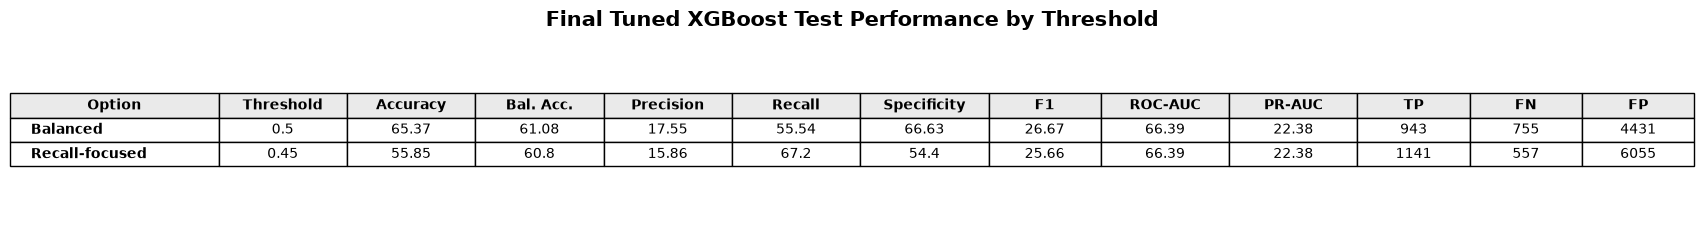

Clean threshold comparison table saved successfully.
PNG: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_threshold_comparison_table.png

Threshold trade-off summary:
--------------------------------------------------------------------------------
Lowering threshold from 0.50 to 0.45 catches 198 additional readmitted patients.
It reduces missed readmissions by 198.
It increases false positives by 1624.

Saved files:
CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_7_final_threshold_comparison_table.csv
PNG: C:\Users\pradh\Documents\hospital-readmission-project\outputs\figures\notebook_7_final_threshold_comparison_table.png


In [ ]:
# Step 5: Final threshold comparison table for report

import matplotlib.pyplot as plt

# 1. Prepare final comparison table from Step 2 results

threshold_comparison = final_test_results.copy()

# Add easy interpretation columns
threshold_comparison["readmissions_caught"] = threshold_comparison["true_positives"]
threshold_comparison["readmissions_missed"] = threshold_comparison["false_negatives"]
threshold_comparison["extra_review_flags"] = threshold_comparison["false_positives"]

# Convert metrics to percentages for display
display_table = threshold_comparison[
    [
        "operating_point",
        "threshold",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "readmissions_caught",
        "readmissions_missed",
        "extra_review_flags",
    ]
].copy()

percentage_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1_score",
    "roc_auc",
    "pr_auc",
]

display_table[percentage_columns] = display_table[percentage_columns] * 100

display_table = display_table.rename(
    columns={
        "operating_point": "Operating Point",
        "threshold": "Threshold",
        "accuracy": "Accuracy (%)",
        "balanced_accuracy": "Balanced Accuracy (%)",
        "precision": "Precision (%)",
        "recall_sensitivity": "Recall (%)",
        "specificity": "Specificity (%)",
        "f1_score": "F1 Score (%)",
        "roc_auc": "ROC-AUC (%)",
        "pr_auc": "PR-AUC (%)",
        "readmissions_caught": "Readmissions Caught",
        "readmissions_missed": "Readmissions Missed",
        "extra_review_flags": "False Positives",
    }
)

display_table = display_table.round(2)

print("Final Tuned XGBoost Threshold Comparison on Test Set")
print("-" * 120)
print(display_table.to_string(index=False))

# 2. Save CSV version

threshold_comparison_csv_path = (
    METRICS_PATH
    / "notebook_7_final_threshold_comparison_table.csv"
)

display_table.to_csv(
    threshold_comparison_csv_path,
    index=False
)

# 3. Create clean professor/report-ready PNG table

clean_table = display_table.copy()

clean_table = clean_table.rename(
    columns={
        "Operating Point": "Option",
        "Threshold": "Threshold",
        "Accuracy (%)": "Accuracy",
        "Balanced Accuracy (%)": "Bal. Acc.",
        "Precision (%)": "Precision",
        "Recall (%)": "Recall",
        "Specificity (%)": "Specificity",
        "F1 Score (%)": "F1",
        "ROC-AUC (%)": "ROC-AUC",
        "PR-AUC (%)": "PR-AUC",
        "Readmissions Caught": "TP",
        "Readmissions Missed": "FN",
        "False Positives": "FP",
    }
)

clean_table["Option"] = [
    "Balanced",
    "Recall-focused"
]

clean_table = clean_table[
    [
        "Option",
        "Threshold",
        "Accuracy",
        "Bal. Acc.",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "TP",
        "FN",
        "FP",
    ]
]

fig, ax = plt.subplots(figsize=(17, 2.4))
ax.axis("off")

column_widths = [
    0.13,  # Option
    0.08,  # Threshold
    0.08,  # Accuracy
    0.08,  # Balanced Accuracy
    0.08,  # Precision
    0.08,  # Recall
    0.08,  # Specificity
    0.07,  # F1
    0.08,  # ROC-AUC
    0.08,  # PR-AUC
    0.07,  # TP
    0.07,  # FN
    0.07,  # FP
]

table = ax.table(
    cellText=clean_table.values,
    colLabels=clean_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=column_widths,
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Header styling
for column_index in range(len(clean_table.columns)):
    table[(0, column_index)].set_text_props(weight="bold")
    table[(0, column_index)].set_facecolor("#EAEAEA")

# Option column styling
for row_index in range(1, len(clean_table) + 1):
    table[(row_index, 0)].set_text_props(ha="left", weight="bold")

plt.title(
    "Final Tuned XGBoost Test Performance by Threshold",
    fontsize=15,
    fontweight="bold",
    pad=10,
)

plt.tight_layout()

threshold_comparison_png_path = (
    FIGURES_PATH
    / "notebook_7_final_threshold_comparison_table.png"
)

plt.savefig(
    threshold_comparison_png_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Clean threshold comparison table saved successfully.")
print(f"PNG: {threshold_comparison_png_path}")

# 4. Print final interpretation

main_row = final_test_results[
    final_test_results["threshold"] == 0.50
].iloc[0]

recall_row = final_test_results[
    final_test_results["threshold"] == 0.45
].iloc[0]

additional_readmissions_caught = (
    recall_row["true_positives"] - main_row["true_positives"]
)

additional_false_positives = (
    recall_row["false_positives"] - main_row["false_positives"]
)

reduced_false_negatives = (
    main_row["false_negatives"] - recall_row["false_negatives"]
)

print("\nThreshold trade-off summary:")
print("-" * 80)
print(f"Lowering threshold from 0.50 to 0.45 catches {additional_readmissions_caught} additional readmitted patients.")
print(f"It reduces missed readmissions by {reduced_false_negatives}.")
print(f"It increases false positives by {additional_false_positives}.")
print("\nSaved files:")
print(f"CSV: {threshold_comparison_csv_path}")
print(f"PNG: {threshold_comparison_png_path}")

In [ ]:
# Step 6: Save final evaluation summary and conclusion

import json
import pandas as pd
from datetime import datetime

# 1. Extract threshold rows

balanced_row = final_test_results[
    final_test_results["threshold"] == 0.50
].iloc[0]

recall_row = final_test_results[
    final_test_results["threshold"] == 0.45
].iloc[0]

additional_readmissions_caught = int(
    recall_row["true_positives"] - balanced_row["true_positives"]
)

reduced_false_negatives = int(
    balanced_row["false_negatives"] - recall_row["false_negatives"]
)

additional_false_positives = int(
    recall_row["false_positives"] - balanced_row["false_positives"]
)

# 2. Create final summary dictionary

final_evaluation_summary = {
    "notebook": "07_final_test_evaluation.ipynb",
    "final_model": "Tuned XGBoost",
    "model_source": str(FINAL_MODEL_PATH),
    "preprocessor_source": str(PREPROCESSOR_PATH),
    "test_set_rows": int(len(y_test)),
    "test_positive_class_rate": float(y_test.mean()),
    "test_readmitted_count": int(y_test.sum()),
    "test_not_readmitted_count": int((y_test == 0).sum()),
    "thresholds_evaluated": [0.50, 0.45],
    "main_balanced_threshold": {
        "threshold": 0.50,
        "accuracy": float(balanced_row["accuracy"]),
        "balanced_accuracy": float(balanced_row["balanced_accuracy"]),
        "precision": float(balanced_row["precision"]),
        "recall": float(balanced_row["recall_sensitivity"]),
        "specificity": float(balanced_row["specificity"]),
        "f1_score": float(balanced_row["f1_score"]),
        "roc_auc": float(balanced_row["roc_auc"]),
        "pr_auc": float(balanced_row["pr_auc"]),
        "true_positives": int(balanced_row["true_positives"]),
        "false_negatives": int(balanced_row["false_negatives"]),
        "false_positives": int(balanced_row["false_positives"]),
        "true_negatives": int(balanced_row["true_negatives"]),
    },
    "recall_focused_threshold": {
        "threshold": 0.45,
        "accuracy": float(recall_row["accuracy"]),
        "balanced_accuracy": float(recall_row["balanced_accuracy"]),
        "precision": float(recall_row["precision"]),
        "recall": float(recall_row["recall_sensitivity"]),
        "specificity": float(recall_row["specificity"]),
        "f1_score": float(recall_row["f1_score"]),
        "roc_auc": float(recall_row["roc_auc"]),
        "pr_auc": float(recall_row["pr_auc"]),
        "true_positives": int(recall_row["true_positives"]),
        "false_negatives": int(recall_row["false_negatives"]),
        "false_positives": int(recall_row["false_positives"]),
        "true_negatives": int(recall_row["true_negatives"]),
    },
    "threshold_tradeoff": {
        "additional_readmissions_caught_at_045": additional_readmissions_caught,
        "reduced_false_negatives_at_045": reduced_false_negatives,
        "additional_false_positives_at_045": additional_false_positives,
    },
    "final_interpretation": (
        "Tuned XGBoost was selected as the final model. "
        "Threshold 0.50 is used as the main balanced option, while threshold 0.45 "
        "is presented as a recall-focused clinical screening option. "
        "Lowering the threshold increases recall and catches more readmitted patients, "
        "but also increases false positives."
    ),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# 3. Save JSON summary

final_summary_json_path = (
    ARTIFACTS_PATH
    / "notebook_7_final_test_evaluation_summary.json"
)

with open(final_summary_json_path, "w") as file:
    json.dump(final_evaluation_summary, file, indent=4)

# 4. Save completion summary CSV

completion_summary = pd.DataFrame(
    [
        {
            "item": "Final model",
            "value": "Tuned XGBoost",
        },
        {
            "item": "Main balanced threshold",
            "value": "0.50",
        },
        {
            "item": "Recall-focused threshold",
            "value": "0.45",
        },
        {
            "item": "Test rows",
            "value": len(y_test),
        },
        {
            "item": "Threshold 0.50 accuracy",
            "value": f"{balanced_row['accuracy'] * 100:.2f}%",
        },
        {
            "item": "Threshold 0.50 recall",
            "value": f"{balanced_row['recall_sensitivity'] * 100:.2f}%",
        },
        {
            "item": "Threshold 0.45 accuracy",
            "value": f"{recall_row['accuracy'] * 100:.2f}%",
        },
        {
            "item": "Threshold 0.45 recall",
            "value": f"{recall_row['recall_sensitivity'] * 100:.2f}%",
        },
        {
            "item": "Additional readmissions caught at threshold 0.45",
            "value": additional_readmissions_caught,
        },
        {
            "item": "Additional false positives at threshold 0.45",
            "value": additional_false_positives,
        },
    ]
)

completion_summary_path = (
    METRICS_PATH
    / "notebook_7_completion_summary.csv"
)

completion_summary.to_csv(
    completion_summary_path,
    index=False
)
# 5. Print final notebook conclusion

print("Notebook 7 Final Test Evaluation Completed")
print("-" * 90)

print("Final model: Tuned XGBoost")
print("Main threshold: 0.50")
print("Recall-focused threshold: 0.45")

print("\nFinal test performance:")
print(
    f"Threshold 0.50 -> Accuracy: {balanced_row['accuracy'] * 100:.2f}%, "
    f"Recall: {balanced_row['recall_sensitivity'] * 100:.2f}%, "
    f"TP: {int(balanced_row['true_positives'])}, "
    f"FN: {int(balanced_row['false_negatives'])}, "
    f"FP: {int(balanced_row['false_positives'])}"
)

print(
    f"Threshold 0.45 -> Accuracy: {recall_row['accuracy'] * 100:.2f}%, "
    f"Recall: {recall_row['recall_sensitivity'] * 100:.2f}%, "
    f"TP: {int(recall_row['true_positives'])}, "
    f"FN: {int(recall_row['false_negatives'])}, "
    f"FP: {int(recall_row['false_positives'])}"
)

print("\nThreshold trade-off:")
print(
    f"Lowering the threshold from 0.50 to 0.45 catches "
    f"{additional_readmissions_caught} additional readmitted patients."
)
print(
    f"It reduces missed readmissions by {reduced_false_negatives}, "
    f"but increases false positives by {additional_false_positives}."
)

print("\nSaved files:")
print(f"Final metrics CSV: {threshold_comparison_csv_path}")
print(f"Final summary JSON: {final_summary_json_path}")
print(f"Completion summary CSV: {completion_summary_path}")

print("\nNotebook 7 is complete.")

Notebook 7 Final Test Evaluation Completed
------------------------------------------------------------------------------------------
Final model: Tuned XGBoost
Main threshold: 0.50
Recall-focused threshold: 0.45

Final test performance:
Threshold 0.50 -> Accuracy: 65.37%, Recall: 55.54%, TP: 943, FN: 755, FP: 4431
Threshold 0.45 -> Accuracy: 55.85%, Recall: 67.20%, TP: 1141, FN: 557, FP: 6055

Threshold trade-off:
Lowering the threshold from 0.50 to 0.45 catches 198 additional readmitted patients.
It reduces missed readmissions by 198, but increases false positives by 1624.

Saved files:
Final metrics CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_7_final_threshold_comparison_table.csv
Final summary JSON: C:\Users\pradh\Documents\hospital-readmission-project\artifacts\notebook_7_final_test_evaluation_summary.json
Completion summary CSV: C:\Users\pradh\Documents\hospital-readmission-project\outputs\metrics\notebook_7_completion_summary.csv

Notebook